# `Maranatha.jl` :: Merge and Fit Results

This notebook demonstrates how to split a quadrature study
into multiple runs, save the partial results, and then merge
them into a single dataset for final analysis.

This workflow is useful when:

- computations are too large to run in one batch
- different resolution ranges are generated separately
- results are produced at different times or on different machines
- you want to extend an existing dataset incrementally

The overall workflow is:

1. Define a common integration setup
2. Run several partial quadrature jobs for different `nsamples`
3. Merge the saved result files
4. Load the merged dataset
5. Perform continuum extrapolation and visualization

## Initialize Julia environment

First we configure the Julia runtime and load the
**`Maranatha.jl`** package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha

## Define the common integration setup

We first define a single shared numerical setup that will be
used for all partial runs.

This includes:

- the integrand
- the integration bounds
- the quadrature rule and boundary condition
- the error estimation method
- fitting-related options
- output settings

Only the resolution list `ns` will change between runs.
This ensures that all partial datasets remain compatible
and can later be merged safely.

In this notebook we generate the dataset directly
from Julia code. However, the same workflow can also be
performed using the TOML configuration interface introduced
in the Quick Start notebook. In that case, each batch would
simply be executed with `run_Maranatha("config.toml")`
using different resolution ranges.

In [2]:
integrand(x) = sin(x)

bounds = (0.0, π)
dim = 1

rule = :gauss_p4
boundary = :LU_EXEX

err_method = :forwarddiff   # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation

fit_terms = 4
nerr_terms = 3
ff_shift = 0

use_threads = true

result_string = "1D"
save_path = "."
write_summary = true
save_file = true

true

## Run the first partial batch

We begin by running the quadrature pipeline for the first
subset of resolutions.

Here we compute only a small part of the full dataset.
The resulting JLD2 file will later be merged with the
other partial outputs.

In [3]:
ns = [2, 3]
run_result_part1 = run_Maranatha(
    integrand,
    bounds...;
    dim = dim,
    nsamples = ns,
    rule = rule,
    boundary = boundary,
    err_method = err_method,
    fit_terms = fit_terms,
    nerr_terms = nerr_terms,
    ff_shift = ff_shift,
    use_threads = use_threads,
    name_prefix = result_string,
    save_path = save_path,
    write_summary = write_summary
)

(a = 0.0, b = π, h = [1.5707963267948966, 1.0471975511965976], avg = [1.9999999543942306, 1.9999999983080423], err = NamedTuple[(ks = [8, 10, 12], coeffs = [1.124788539770296e-9, 1.4753719807192386e-10, 3.815912407242014e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787330988e-8, -2.119435374676256e-8, 1.3525608060986144e-9], total = 4.5644404932645934e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099521367e-9, 5.728022157904421e-10, 5.0364674597331475e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.5551694343111364e-9, -9.51304359599064e-10, 9.172718506231512e-11], total = 1.6955922597743876e-9, center = 1.5707963267948966, h = 1.0471975511965976)], rule = :gauss_p4, boundary = :LU_EXEX, dim = 1, err_method = :forwarddiff, nerr_terms = 3, fit_terms = 4, ff_shift = 0, use_threads = true)

## Run the second partial batch

Next we compute a second subset of resolutions using the
same integration setup.

Because the numerical configuration is unchanged, this
dataset is compatible with the first one and can later be
combined into a single result file.

In [4]:
ns = [4, 5, 6]
run_result_part2 = run_Maranatha(
    integrand,
    bounds...;
    dim = dim,
    nsamples = ns,
    rule = rule,
    boundary = boundary,
    err_method = err_method,
    fit_terms = fit_terms,
    nerr_terms = nerr_terms,
    ff_shift = ff_shift,
    use_threads = use_threads,
    name_prefix = result_string,
    save_path = save_path,
    write_summary = write_summary
)

(a = 0.0, b = π, h = [0.7853981633974483, 0.6283185307179586, 0.5235987755982988], avg = [1.999999999833522, 1.9999999999722917, 1.9999999999935836], err = NamedTuple[(ks = [8, 10, 12], coeffs = [2.249577081580957e-9, 1.4198629360317195e-9, 2.489014012038481e-10], derivatives = [1.0, -1.0, 1.0], terms = [2.558054606746321e-10, -9.959444540804312e-11, 1.0769506414225862e-11], total = 1.6698052168081481e-10, center = 1.5707963267948966, h = 0.7853981633974483), (ks = [8, 10, 12], coeffs = [2.811971362637862e-9, 2.8293179274730013e-9, 8.14120409147748e-10], derivatives = [1.0, -1.0, 1.0], terms = [4.2917034839899186e-11, -1.7047484464908643e-11, 1.9365420462773873e-12], total = 2.780609242126793e-11, center = 1.5707963267948966, h = 0.6283185307179586), (ks = [8, 10, 11], coeffs = [3.3743656701286482e-9, 4.941765758430238e-9, 3.6455615751680627e-19], derivatives = [1.0, -1.0, -6.123233995736766e-17], terms = [9.981130751337962e-12, -4.007439746192331e-12, -9.478263144946589e-39], total = 

## Run the third partial batch

Finally we compute the remaining subset of resolutions.

At this stage we have produced three separate result files,
each covering a different range of `nsamples`.

In [5]:
ns = [7, 8, 9]
run_result_part3 = run_Maranatha(
    integrand,
    bounds...;
    dim = dim,
    nsamples = ns,
    rule = rule,
    boundary = boundary,
    err_method = err_method,
    fit_terms = fit_terms,
    nerr_terms = nerr_terms,
    ff_shift = ff_shift,
    use_threads = use_threads,
    name_prefix = result_string,
    save_path = save_path,
    write_summary = write_summary
)

(a = 0.0, b = π, h = [0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999999981357, 1.9999999999993603, 1.9999999999997509], err = NamedTuple[(ks = [8, 9, 10], coeffs = [3.936760087584382e-9, 5.012647165856086e-17, 7.897805015065189e-9], derivatives = [1.0, 6.123233995736766e-17, -1.0], terms = [2.908073930113588e-12, 1.0175747434087581e-36, -1.1751047098474008e-12], total = 1.7329692202661873e-12, center = 1.5707963267948966, h = 0.4487989505128276), (ks = [8, 9, 10], coeffs = [4.499154437369379e-9, 2.205564752976678e-16, 1.1838034239459646e-8], derivatives = [1.0, 6.123233995736766e-17, -1.0], terms = [9.992401416604151e-13, 1.177875872412883e-36, -4.054509613385327e-13], total = 5.937891803218824e-13, center = 1.5707963267948966, h = 0.39269908169872414), (ks = [8, 9, 10], coeffs = [5.061548787154376e-9, 8.020235465369738e-16, 1.6903052003019387e-8], derivatives = [1.0, 6.123233995736766e-17, -1.0], terms = [3.894481961106835e-13, 1.3189903175570621e-36, -

All input files should correspond to the same integrand setup
and differ only in their sampled resolution sets.

## Merge partial result files

The function `merge_datapoint_result_files` combines multiple
saved result files into a single merged dataset.

This is useful when the full resolution sequence was generated
in separate batches. The merged file can then be analyzed in
the same way as a dataset produced by a single `run_Maranatha`
call.

In [6]:
merged_file = merge_datapoint_result_files(
    "result_$(result_string)_$(rule)_$(boundary)_N_2_3.jld2",
    "result_$(result_string)_$(rule)_$(boundary)_N_4_5_6.jld2",
    "result_$(result_string)_$(rule)_$(boundary)_N_7_8_9.jld2";
    output_path = "result_merged.jld2",
    write_summary=true
)

"result_merged.jld2"

## Load the merged dataset

After merging, we load the combined JLD2 file back into Julia.

The returned object has the same structure as an ordinary
`run_Maranatha` result, so it can be passed directly to the
fitting and plotting routines.

In [7]:
run_result_merged = load_datapoint_results(merged_file)

(a = 0.0, b = 3.141592653589793, h = [1.5707963267948966, 1.0471975511965976, 0.7853981633974483, 0.6283185307179586, 0.5235987755982988, 0.4487989505128276, 0.39269908169872414, 0.3490658503988659], avg = [1.9999999543942306, 1.9999999983080423, 1.999999999833522, 1.9999999999722917, 1.9999999999935836, 1.9999999999981357, 1.9999999999993603, 1.9999999999997509], err = [(ks = [8, 10, 12], coeffs = [1.124788539770296e-9, 1.4753719807192386e-10, 3.815912407242014e-12], derivatives = [1.0, -1.0, 1.0], terms = [6.548619787330988e-8, -2.119435374676256e-8, 1.3525608060986144e-9], total = 4.5644404932645934e-8, center = 1.5707963267948966, h = 1.5707963267948966), (ks = [8, 10, 12], coeffs = [1.6871828099521367e-9, 5.728022157904421e-10, 5.0364674597331475e-11], derivatives = [1.0, -1.0, 1.0], terms = [2.5551694343111364e-9, -9.51304359599064e-10, 9.172718506231512e-11], total = 1.6955922597743876e-9, center = 1.5707963267948966, h = 1.0471975511965976), (ks = [8, 10, 12], coeffs = [2.24957

## Perform continuum extrapolation on the merged data

Now we perform the extrapolation fit using the merged dataset.

This step treats the combined result exactly like a standard
single-run dataset, allowing us to estimate the continuum
limit $h \to 0$ from all available resolutions at once.

In [8]:
fit_result_merged = least_chi_square_fit(
    run_result_merged; 
    nterms = 4, 
    ff_shift = 0, 
    nerr_terms = 3
)

print_fit_result(fit_result_merged)

[2026-03-08 15:37:13.259] residual ks (backend) = [8, 9, 10, 11], fit powers (h^p), ff_shift=0 = [8, 9, 10]
[2026-03-08 15:37:14.964]            λ_0 = 2.00000000000000(39)
[2026-03-08 15:37:14.964]            λ_1 = -0.0000000011(34) *
[2026-03-08 15:37:14.964]            λ_2 = 0.0000000000(79) *
[2026-03-08 15:37:14.964]            λ_3 = -0.0000000000(39) *
[2026-03-08 15:37:14.964] 
[2026-03-08 15:37:14.965] Chi^2 / d.o.f. = 3.966941827232e-06 / 4 = 9.917354568079e-07
[2026-03-08 15:37:14.965] Result (h→0)   = 2.00000000000000(39)
[2026-03-08 15:37:14.965] 


## Visualize convergence of the merged dataset

Finally we visualize the convergence behaviour of the merged
quadrature data.

The resulting plot shows how the combined estimates behave
across the full resolution range, together with the fitted
continuum extrapolation.

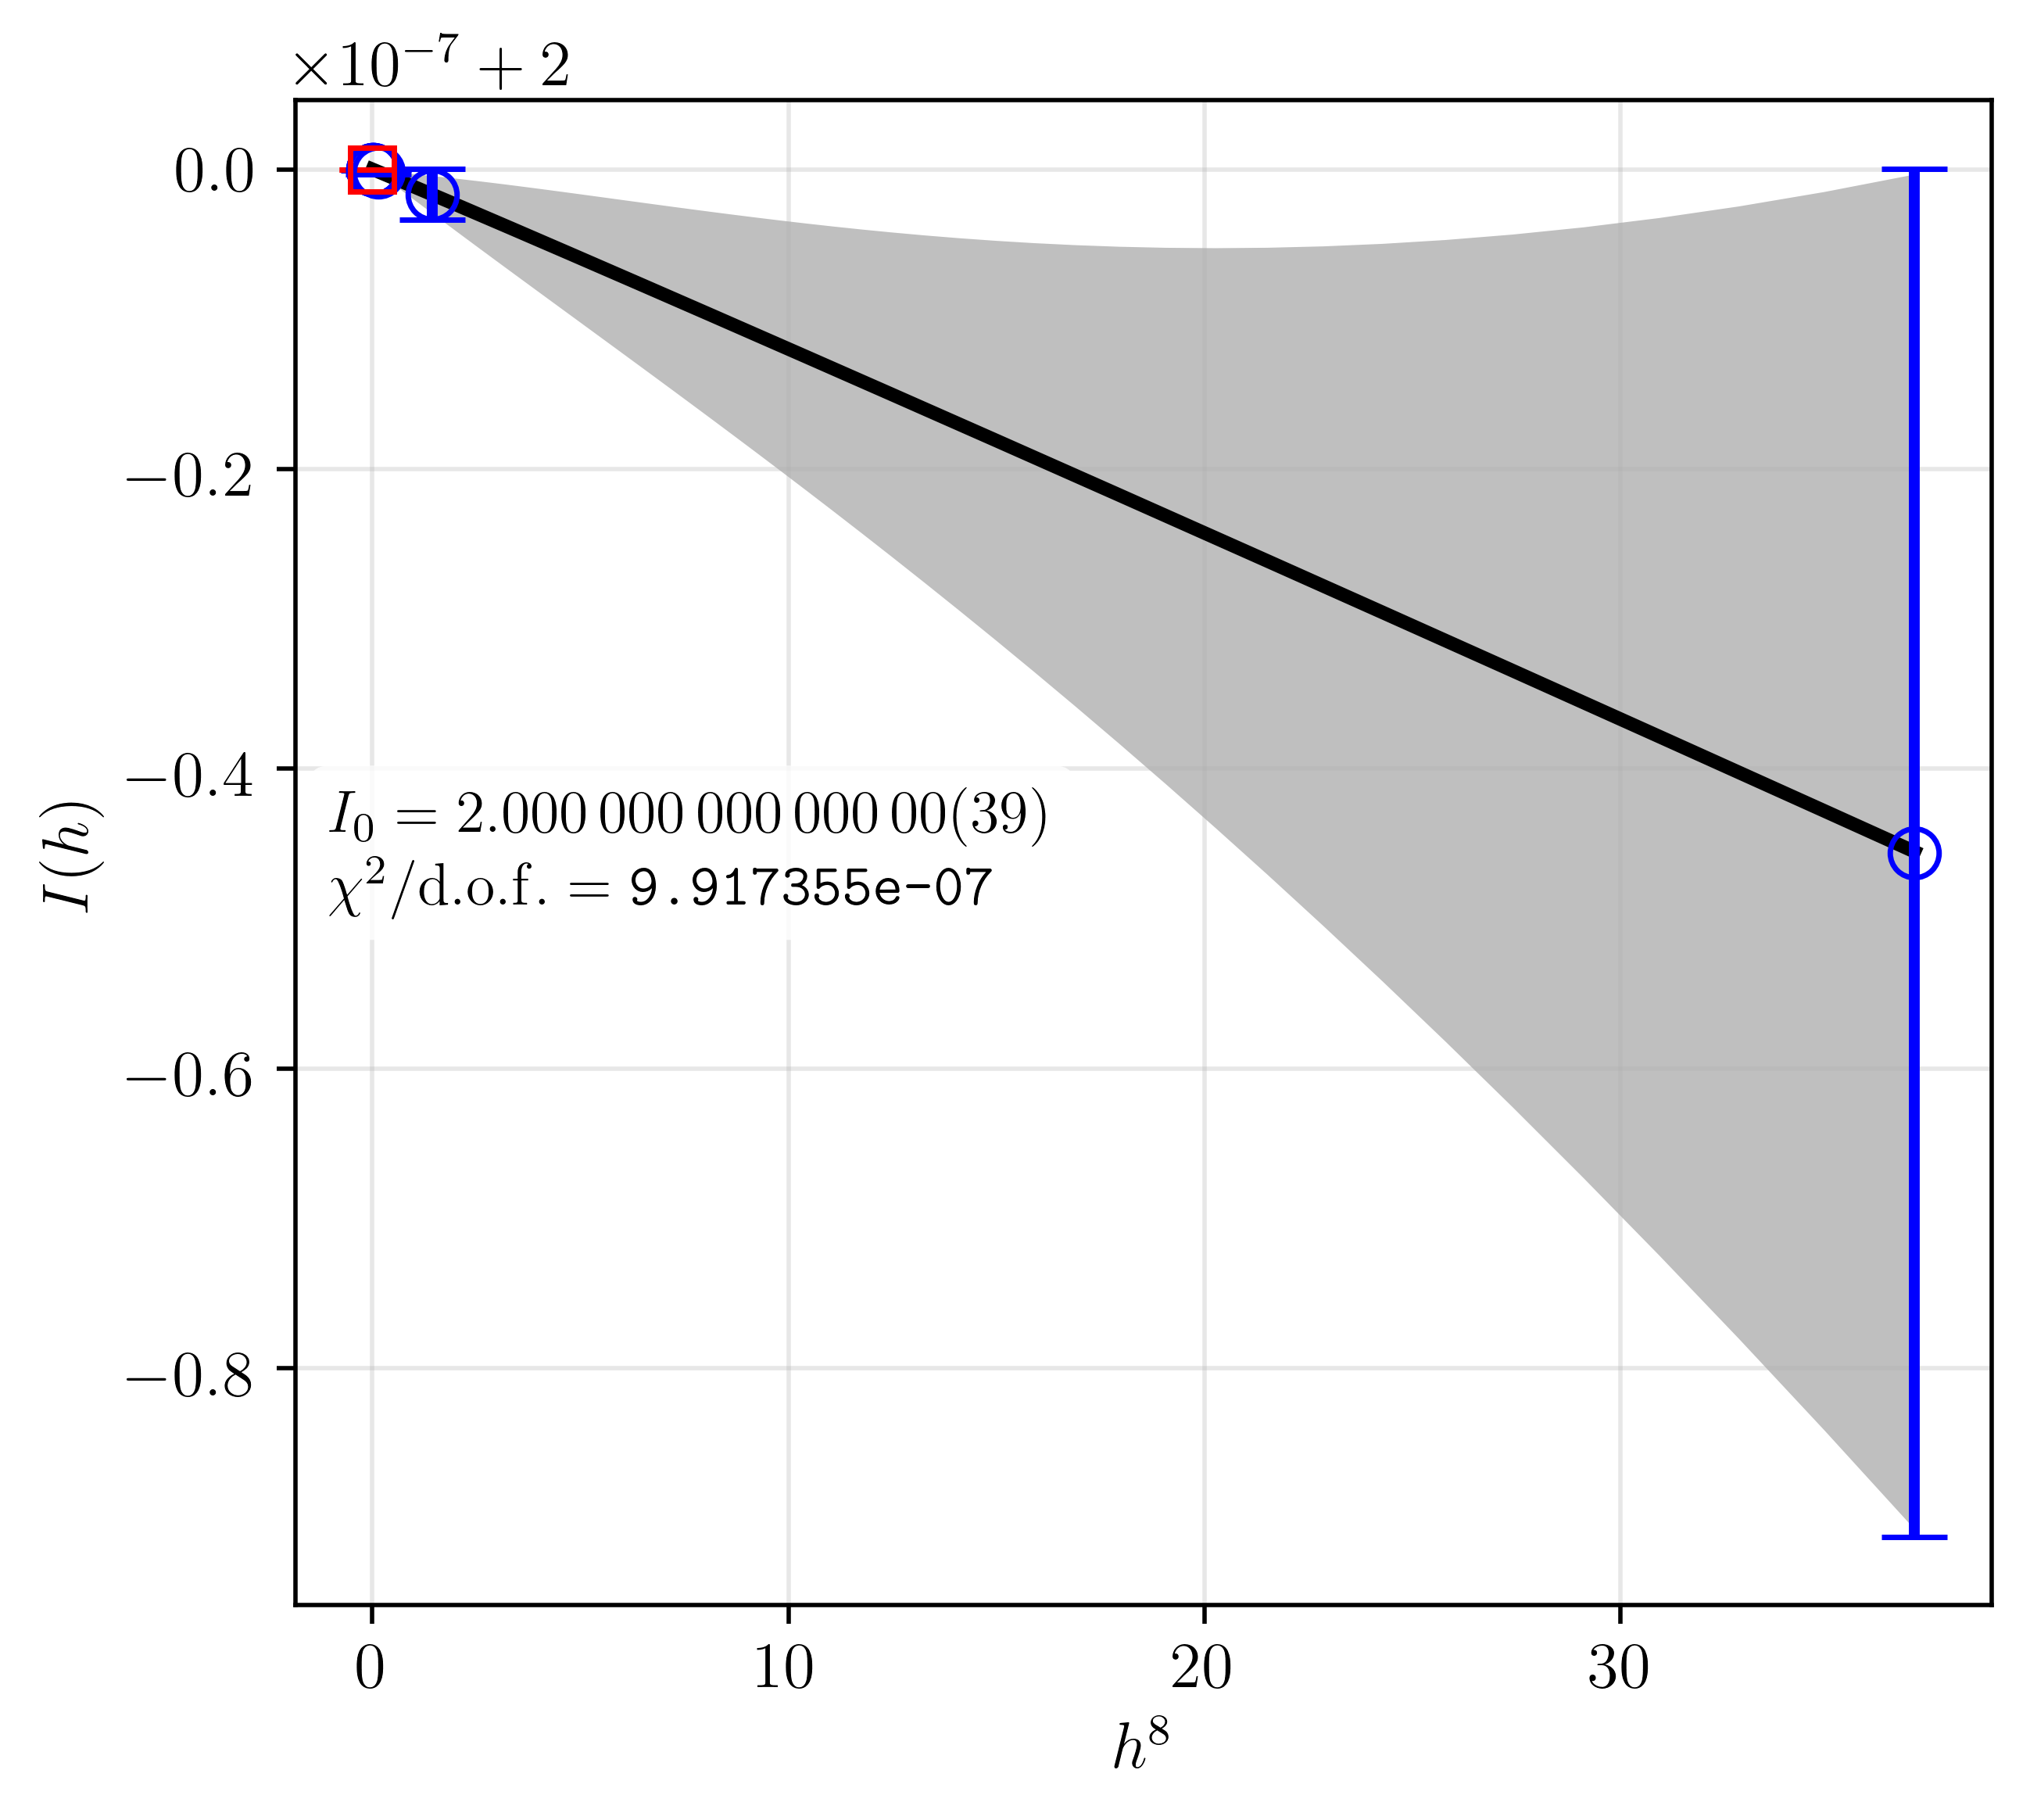

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Maranatha_test3_gauss_p4_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Maranatha_test3_gauss_p4_LU_EXEX_reldiff-crop.pdf'.


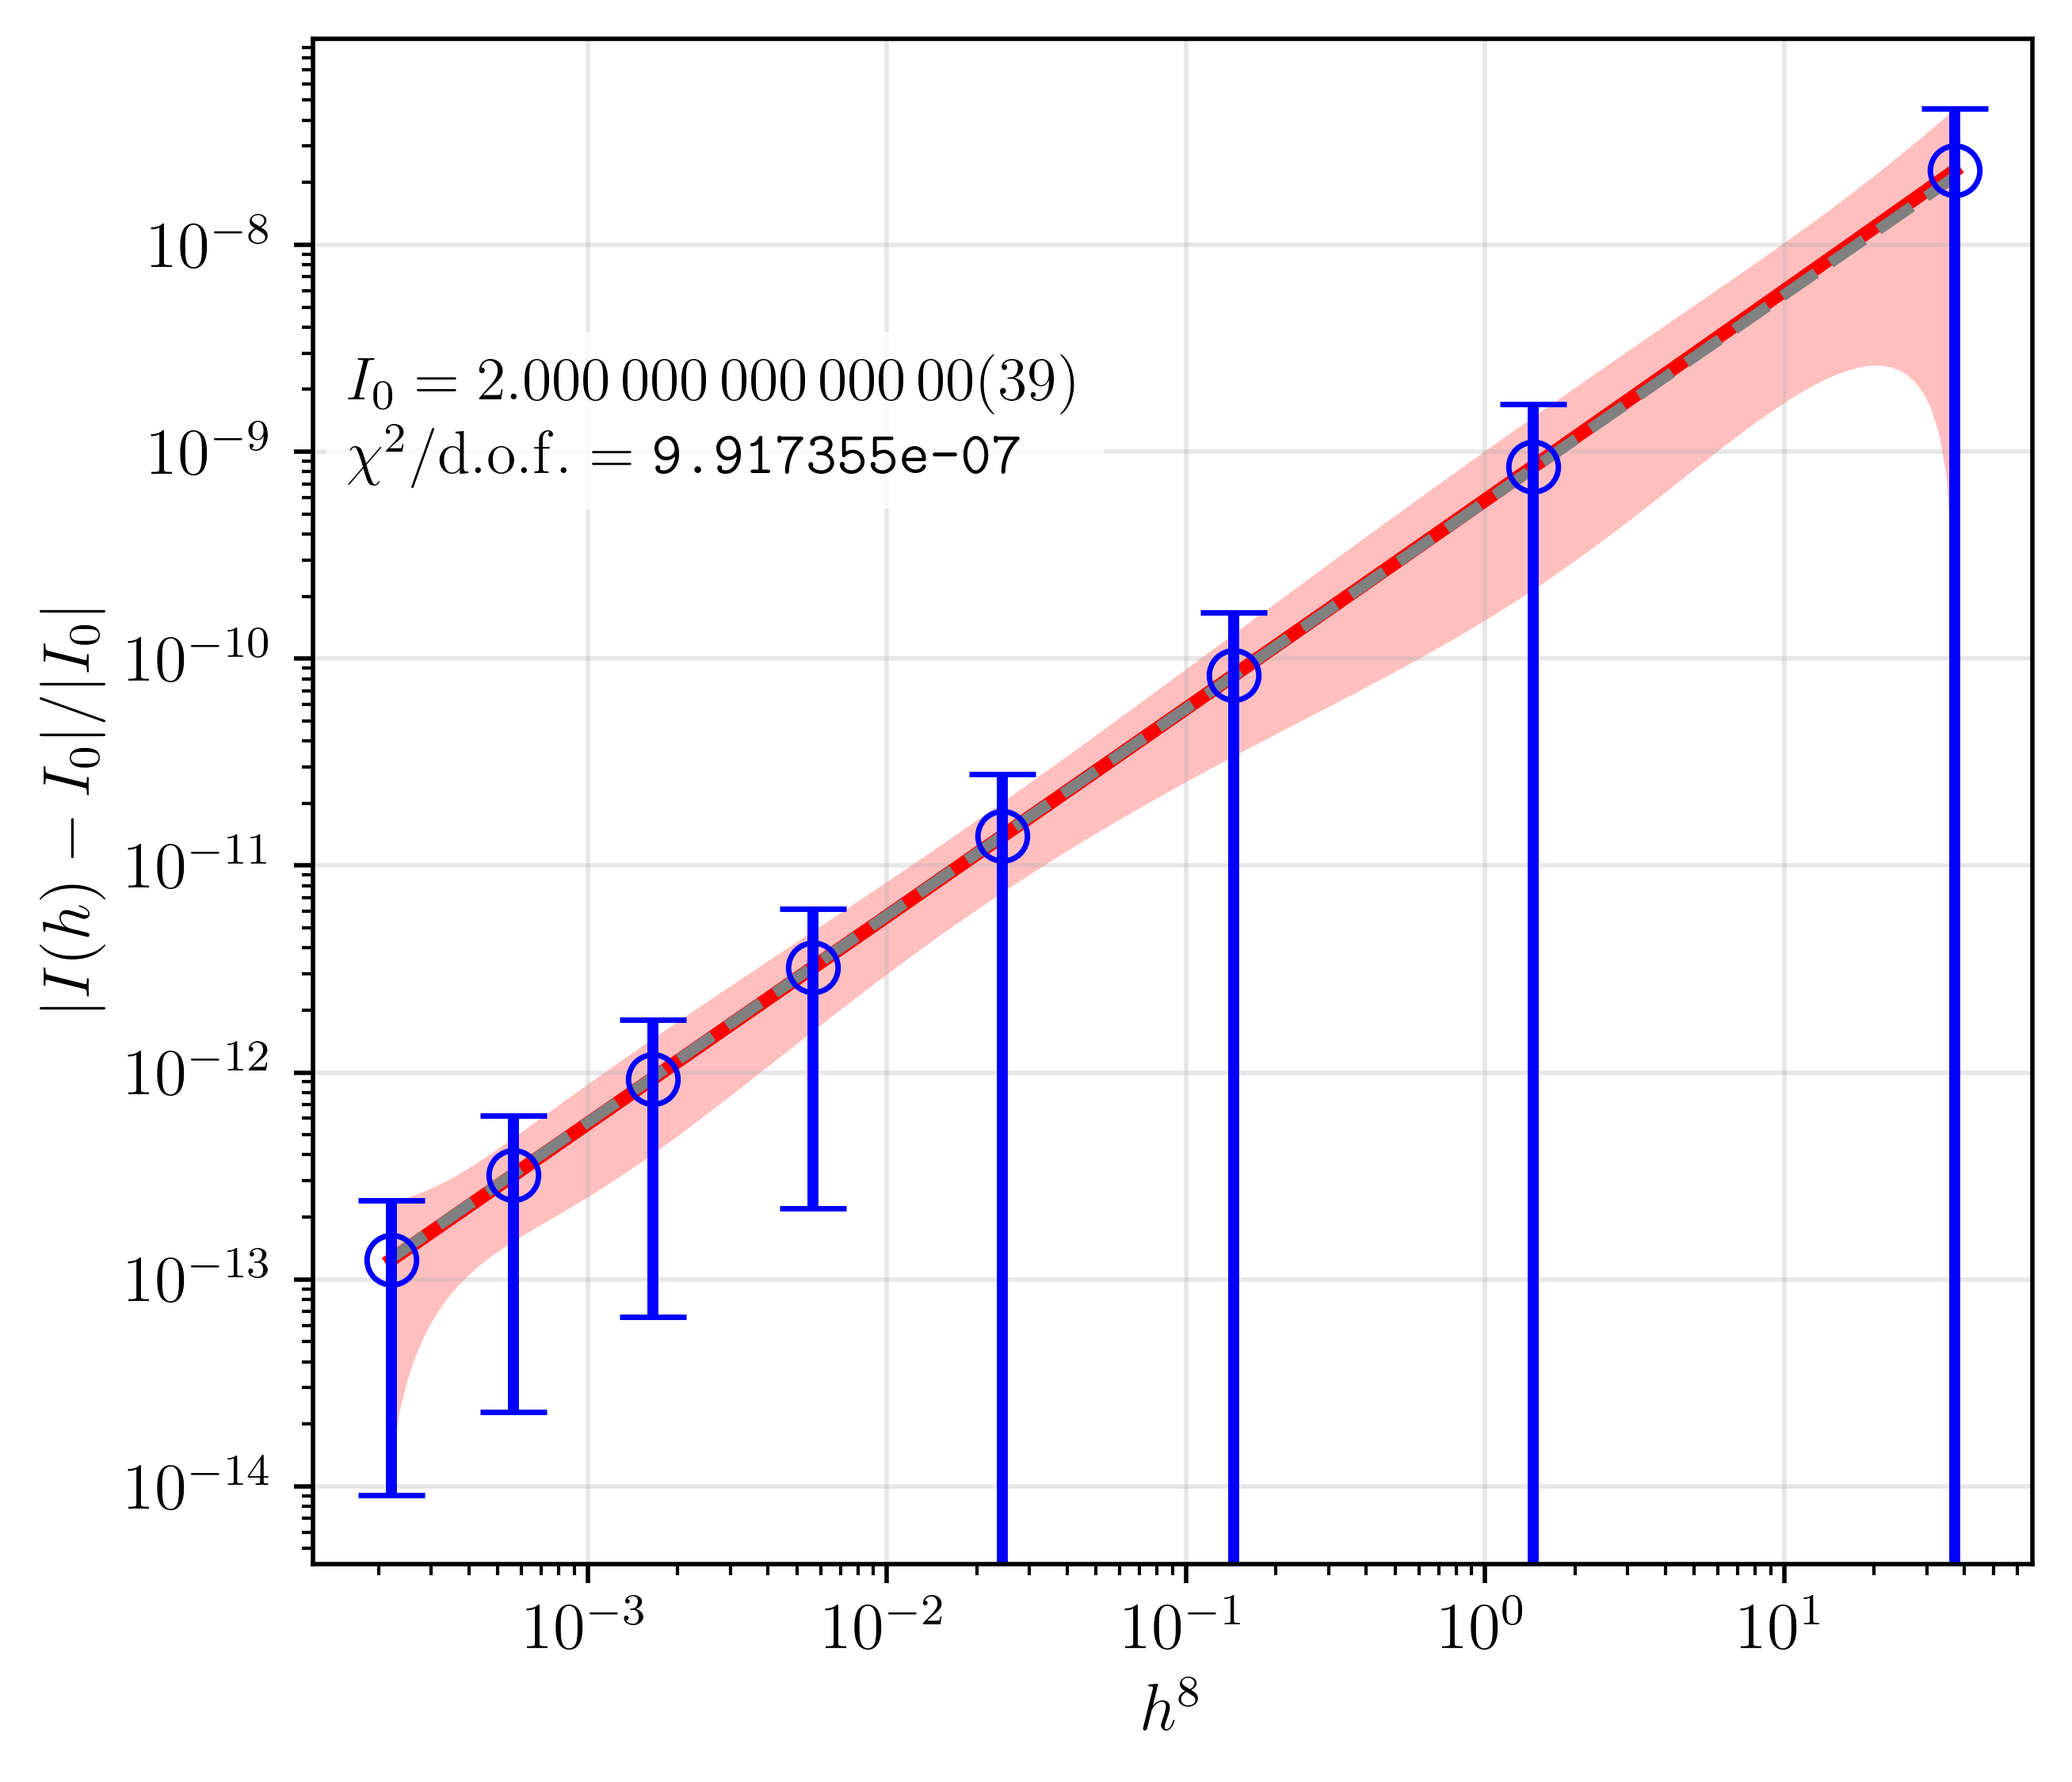

In [9]:
plot_convergence_result(
    run_result_merged, 
    fit_result_merged;
    name="Maranatha_test3",
    figs_dir=".",
    save_file=true)

## Summary

In this notebook we demonstrated how to build a full
quadrature dataset from multiple partial runs.

Workflow:

1. Define one common numerical setup
2. Run separate batches for different `nsamples`
3. Merge the saved result files
4. Load the merged dataset
5. Perform fitting and visualization

This workflow is especially useful for large computations,
incremental dataset construction, or distributed execution
across multiple sessions or machines.